In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

In [2]:
# loading the demand data
demand = pd.read_excel('PGCB_date_power_demand.xlsx')
print(demand.shape)
demand.head()

(92650, 15)


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [3]:
demand['datetime'] = pd.to_datetime(demand['datetime'])
demand = demand.sort_values('datetime')
demand.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
24,2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
22,2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
21,2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
20,2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
19,2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN


In [4]:
# some rows have :30 timestamps so i need to combine them with the hourly ones
demand['base_hour'] = demand['datetime'].dt.floor('h')

def weighted_avg(group):
    weights = np.where(group['datetime'].dt.minute == 0, 2/3, 1/3)
    return pd.Series({'demand_mw': np.average(group['demand_mw'], weights=weights)})

demand = demand.groupby('base_hour').apply(weighted_avg).reset_index()
demand = demand.rename(columns={'base_hour': 'datetime'})
print(demand.shape)
demand.head()

(88050, 2)


,datetime,demand_mw
0,2015-04-19 00:00:00,4821.0
1,2015-04-19 01:00:00,3612.0
2,2015-04-19 02:00:00,3727.0
3,2015-04-19 03:00:00,3632.0
4,2015-04-19 04:00:00,3641.0


In [5]:
# setting datetime as index and filling missing hours using previous value
demand = demand.set_index('datetime')
demand = demand.asfreq('h')
demand = demand.ffill()
print('missing values:', demand.isnull().sum())

missing values: demand_mw    0
dtype: int64


In [6]:
# removing outliers using IQR method
q1 = demand['demand_mw'].quantile(0.25)
q3 = demand['demand_mw'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 3 * iqr
upper = q3 + 3 * iqr

outliers = (demand['demand_mw'] < lower) | (demand['demand_mw'] > upper)
print('outliers found:', outliers.sum())

demand.loc[outliers, 'demand_mw'] = np.nan
demand['demand_mw'] = demand['demand_mw'].interpolate('linear')

outliers found: 8


In [7]:
# loading weather data (first 3 rows are metadata so skipping them)
weather = pd.read_excel('weather_data.xlsx', skiprows=3)
weather.columns = ['datetime', 'temp', 'humidity', 'apparent_temp',
                   'precipitation', 'dew_point', 'soil_temp',
                   'wind_dir', 'cloud_cover', 'sunshine']
weather['datetime'] = pd.to_datetime(weather['datetime'])
weather = weather.set_index('datetime')
weather = weather.resample('h').mean()
weather = weather.interpolate('linear')
print(weather.shape)
weather.head()

(107304, 9)


,temp,humidity,apparent_temp,precipitation,dew_point,soil_temp,wind_dir,cloud_cover,sunshine
datetime,,,,,,,,,
2014-01-01 00:00:00,13.9,89.0,13.3,0.0,12.1,16.4,313.0,0.0,0.0
2014-01-01 01:00:00,13.6,91.0,13.2,0.0,12.1,16.0,317.0,0.0,0.0
2014-01-01 02:00:00,13.3,91.0,12.8,0.0,11.9,15.7,317.0,0.0,0.0
2014-01-01 03:00:00,13.0,92.0,12.5,0.0,11.8,15.4,319.0,0.0,0.0
2014-01-01 04:00:00,12.7,93.0,12.2,0.0,11.6,15.2,322.0,0.0,0.0


In [8]:
# loading economic data
econ = pd.read_csv('economic_full_1.csv')

# picking only useful indicators
indicators = [
    'Access to electricity (% of population)',
    'Electric power consumption (kWh per capita)',
    'GDP (current US$)',
]

econ = econ[econ['Indicator Name'].isin(indicators)]

# year columns are like '2015', '2016' etc
year_cols = [c for c in econ.columns if c.isdigit()]

# converting from wide to long format
econ = econ.melt(id_vars='Indicator Name', value_vars=year_cols, var_name='year', value_name='val')
econ['year'] = econ['year'].astype(int)

# making each indicator a column
econ = econ.pivot_table(index='year', columns='Indicator Name', values='val')
econ.columns = ['elec_access', 'gdp_usd', 'power_per_cap']
econ = econ.reset_index()

# filling missing years
all_years = pd.DataFrame({'year': range(2015, 2025)})
econ = all_years.merge(econ, on='year', how='left')
econ = econ.ffill()
econ = econ.bfill()
print(econ)

   year  elec_access     gdp_usd  power_per_cap
0  2015         74.0  348.932681   1.951470e+11
1  2016         75.9  412.780315   2.652250e+11
2  2017         88.0  443.212946   2.937320e+11
3  2018         86.9  471.126089   3.213630e+11
4  2019         92.2  515.101730   3.512320e+11
5  2020         96.2  509.945927   3.739790e+11
6  2021         99.0  574.118203   4.162720e+11
7  2022         99.4  602.674747   4.601320e+11
8  2023         99.5  602.674747   4.374150e+11
9  2024         99.5  602.674747   4.501190e+11


In [9]:
# merging all three datasets
df = demand.join(weather, how='left')

df['year'] = df.index.year
df = df.reset_index()
df = df.merge(econ, on='year', how='left')
df = df.set_index('datetime')

# keeping only upto 2024
df = df[df.index.year <= 2024]
print(df.shape)

(85080, 14)


In [10]:
# adding time features
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)

# cyclical features so model knows hour 23 and hour 0 are close
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# lag features - past demand values
for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
    df['lag_' + str(lag) + 'h'] = df['demand_mw'].shift(lag)

# adding lag around same time last week
df['lag_167h'] = df['demand_mw'].shift(167)
df['lag_169h'] = df['demand_mw'].shift(169)

# rolling averages
past = df['demand_mw'].shift(1)
df['roll_mean_3h']   = past.rolling(3).mean()
df['roll_mean_24h']  = past.rolling(24).mean()
df['roll_mean_168h'] = past.rolling(168).mean()
df['roll_std_24h']   = past.rolling(24).std()

# temp squared because hot and cold both increase demand
df['temp_sq'] = df['temp'] ** 2

# how much demand changed in last 1h and 24h
df['demand_diff_1h']  = df['demand_mw'].diff(1).shift(1)
df['demand_diff_24h'] = df['demand_mw'].diff(24).shift(1)

# target is next hour demand
df['target'] = df['demand_mw'].shift(-1)

df = df.dropna()
print('final shape:', df.shape)

final shape: (84910, 39)


In [11]:
# train test split - train on 2015 to 2023, test on 2024
drop_cols = ['target', 'demand_mw', 'year']
features = [c for c in df.columns if c not in drop_cols]

X = df[features]
y = df['target']

X_train = X[X.index.year <= 2023]
y_train = y[y.index.year <= 2023]

X_test = X[X.index.year == 2024]
y_test = y[y.index.year == 2024]

print('train size:', len(X_train))
print('test size:', len(X_test))

train size: 76127
test size: 8783


In [12]:
# training xgboost model
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train, verbose=False)
print('model trained')

model trained


In [13]:
# checking performance on 2024
preds = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, preds) * 100
mae  = np.mean(np.abs(y_test.values - preds))

print('Test MAPE:', round(mape, 2), '%')
print('Test MAE :', round(mae, 1), 'MW')

Test MAPE: 4.97 %
Test MAE : 330.7 MW


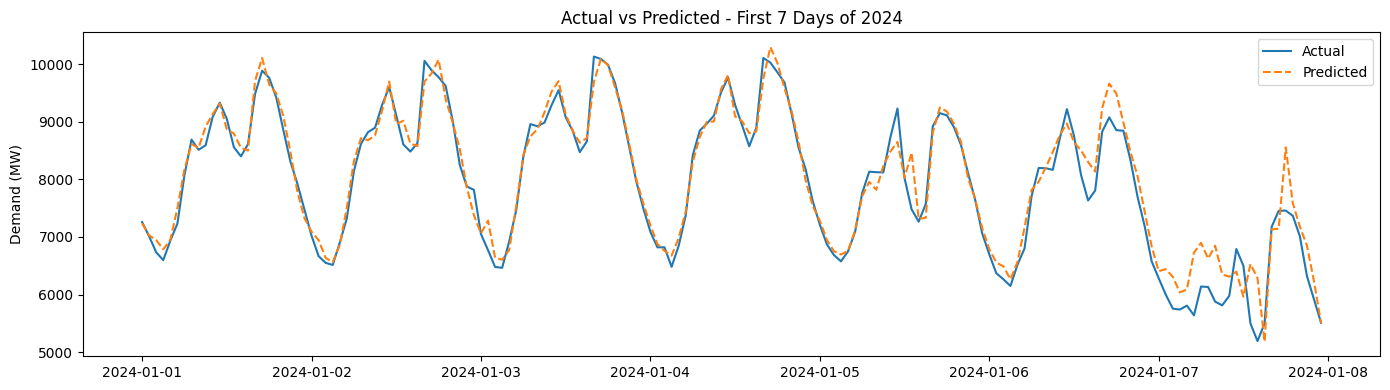

In [14]:
# plotting actual vs predicted for first week of 2024
plt.figure(figsize=(14, 4))
plt.plot(y_test.index[:168], y_test.values[:168], label='Actual')
plt.plot(y_test.index[:168], preds[:168], label='Predicted', linestyle='--')
plt.title('Actual vs Predicted - First 7 Days of 2024')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

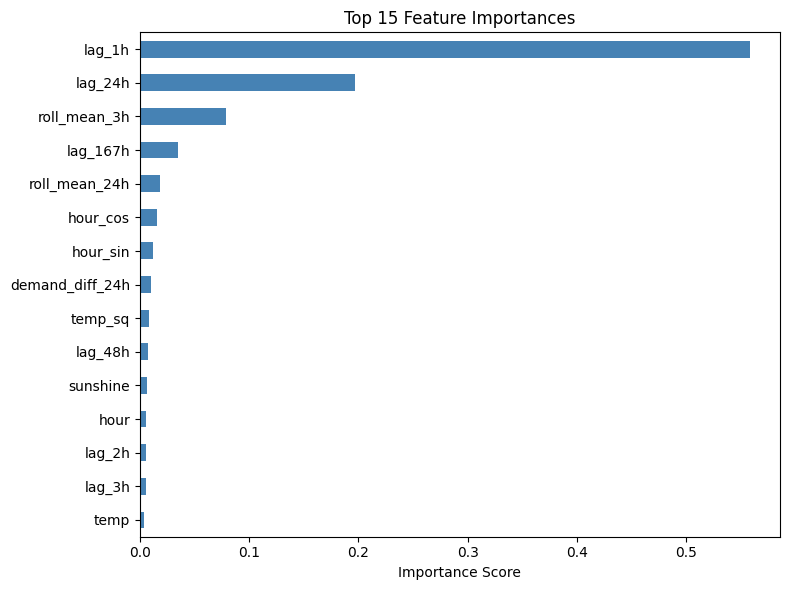

In [15]:
# features that are most important
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.nlargest(15).sort_values()

plt.figure(figsize=(8, 6))
importance.plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()